# 🚗 TMS2 - YOLOv8 Fine-tuning

Fine-tune YOLOv8 on your uploaded traffic datasets.

### Your Data:
| Dataset | Images | Use |
|---------|--------|-----|
| ⭐ UA-DETRAC | ~20K | Primary training |
| Real-Time Traffic | 500 videos | Training |
| Serbia Traffic | - | Training |

---

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/tms2_colab_training'
MODEL_PATH = f'{DRIVE_PATH}/models'
DATA_PATH = f'{DRIVE_PATH}/data'
KAGGLE_PATH = f'{DATA_PATH}/kaggle'

import os
os.makedirs(f'{DATA_PATH}/yolo_dataset/images/train', exist_ok=True)
os.makedirs(f'{DATA_PATH}/yolo_dataset/images/val', exist_ok=True)
os.makedirs(f'{DATA_PATH}/yolo_dataset/labels/train', exist_ok=True)
os.makedirs(f'{DATA_PATH}/yolo_dataset/labels/val', exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

Mounted at /content/drive


In [2]:
!pip install -q ultralytics opencv-python

import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.4 MB/s eta 0:00:00
CUDA: True
GPU: Tesla T4


In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
import glob
from tqdm import tqdm
import random
import shutil
from pathlib import Path

print("Libraries loaded!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries loaded!


## 2. ⚙️ CONFIGURATION

**Edit these to customize training:**

In [9]:
# ============================================================
# ⚙️ CONFIGURATION - EDIT THESE VALUES
# ============================================================

# === DATA SETTINGS ===
MAX_SAMPLES_PER_DATASET = None    # Max images from each dataset
VAL_SPLIT = 0.2                   # 20% for validation
PSEUDO_LABEL_CONF = 0.5           # Confidence for pseudo-labels

# === TRAINING SETTINGS ===
EPOCHS = 50                       # Training epochs
BATCH_SIZE = 16                   # Batch size (reduce if OOM)
IMAGE_SIZE = 640                  # Image size
PATIENCE = 15                     # Early stopping patience

# === WHICH DATASETS TO USE ===
USE_DATASETS = {
    'ua-detrac': True,            # ⭐ 20K images
    'real-time-traffic': True,    # 500 videos
    'serbia-traffic': True,       # Videos/images
    'highway-traffic-videos': True,
}

print("📊 Configuration:")
print(f"  Samples/dataset: {MAX_SAMPLES_PER_DATASET}")
print(f"  Val split: {VAL_SPLIT}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch: {BATCH_SIZE}")

📊 Configuration:
  Samples/dataset: None
  Val split: 0.2
  Epochs: 50
  Batch: 16


## 3. Discover Datasets

In [19]:
DATASETS = {
    'ua-detrac': {'path': f'{KAGGLE_PATH}/UA_DETRAC', 'has_labels': True},
    'real-time-traffic': {'path': f'{KAGGLE_PATH}/RealTime_Traffic_Videos', 'has_labels': True},
    'serbia-traffic': {'path': f'{KAGGLE_PATH}/RoadTraffic_Serbia', 'has_labels': True},
    'highway-traffic-videos': {'path': f'{KAGGLE_PATH}/highway-traffic-videos', 'has_labels': False},
    'Traffic_Density_Singapore': {'path': f'{KAGGLE_PATH}/Traffic_Density_Singapore', 'has_labels': False},
    'LISA_Traffic_Light': {'path': f'{KAGGLE_PATH}/LISA_Traffic_Light', 'has_labels': False},
}

available = []
print("🔍 Checking datasets...\n")

for name, cfg in DATASETS.items():
    path = cfg['path']
    if os.path.exists(path):
        images = glob.glob(f'{path}/**/*.jpg', recursive=True)
        images += glob.glob(f'{path}/**/*.png', recursive=True)
        videos = glob.glob(f'{path}/**/*.avi', recursive=True)
        videos += glob.glob(f'{path}/**/*.mp4', recursive=True)
        videos += glob.glob(f'{path}/**/*.MOV', recursive=True)
        videos += glob.glob(f'{path}/**/*.mov', recursive=True)
        labels = glob.glob(f'{path}/**/*.txt', recursive=True)

        available.append({
            'name': name,
            'path': path,
            'images': images,
            'videos': videos,
            'has_labels': len(labels) > 0 or cfg['has_labels']
        })
        print(f"✅ {name}: {len(images)} images, {len(videos)} videos")
    else:
        print(f"❌ {name}: Not found")

print(f"\n📊 {len(available)} datasets available")

🔍 Checking datasets...

✅ ua-detrac: 13452 images, 0 videos
✅ real-time-traffic: 0 images, 2 videos
✅ serbia-traffic: 71 images, 5 videos
✅ highway-traffic-videos: 0 images, 254 videos
✅ Traffic_Density_Singapore: 4027 images, 0 videos
✅ LISA_Traffic_Light: 44075 images, 0 videos

📊 6 datasets available


## 4. Quick Test Pre-trained Model

In [20]:
model = YOLO('yolov8n.pt')
VEHICLE_CLASSES = {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
print("Pre-trained YOLOv8n loaded!")

Pre-trained YOLOv8n loaded!


Testing on: ua-detrac

0: 384x640 10 persons, 8 cars, 8.9ms
Speed: 3.1ms preprocess, 8.9ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)


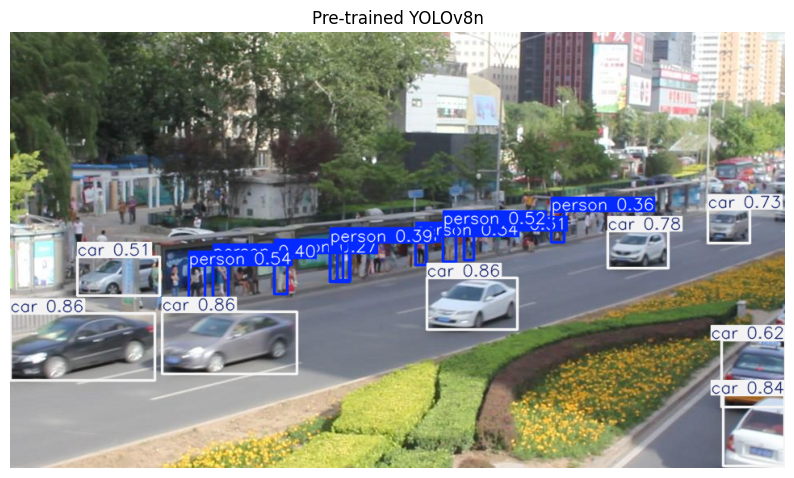

In [21]:
# Test on sample
import matplotlib.pyplot as plt

test_frame = None
for ds in available:
    if ds['images']:
        test_frame = cv2.imread(ds['images'][0])
        print(f"Testing on: {ds['name']}")
        break

if test_frame is not None:
    results = model(test_frame)
    annotated = results[0].plot()

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("Pre-trained YOLOv8n")
    plt.axis('off')
    plt.show()

## 5. Prepare Training Data

In [22]:
def copy_with_labels(dataset, output_dir, max_samples, val_split):
    """Copy images that have YOLO-format labels."""
    images_dir = Path(output_dir) / 'images'
    labels_dir = Path(output_dir) / 'labels'
    copied = 0

    for img_path in tqdm(dataset['images'][:max_samples], desc=dataset['name']):
        img = Path(img_path)

        # Find label
        label = img.with_suffix('.txt')
        if not label.exists():
            label = img.parent.parent / 'labels' / img.with_suffix('.txt').name

        if label.exists():
            split = 'val' if random.random() < val_split else 'train'
            shutil.copy(img, images_dir / split / f"{dataset['name']}_{img.name}")
            shutil.copy(label, labels_dir / split / f"{dataset['name']}_{label.name}")
            copied += 1

    return copied


def create_pseudo_labels(dataset, output_dir, model, max_samples, val_split, conf=0.5):
    """Create pseudo-labels for videos without annotations."""
    images_dir = Path(output_dir) / 'images'
    labels_dir = Path(output_dir) / 'labels'
    count = 0

    for video in tqdm(dataset['videos'][:50], desc=f"{dataset['name']} (pseudo)"):
        cap = cv2.VideoCapture(video)
        video_name = Path(video).stem
        frame_idx = 0

        while cap.isOpened() and count < max_samples:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % 30 == 0:
                results = model(frame, verbose=False)
                labels = []

                for result in results:
                    for box in result.boxes:
                        cls = int(box.cls[0])
                        if cls in VEHICLE_CLASSES and float(box.conf[0]) >= conf:
                            x, y, w, h = box.xywhn[0].tolist()
                            class_map = {2: 0, 3: 1, 5: 2, 7: 3}
                            labels.append(f"{class_map[cls]} {x} {y} {w} {h}")

                if labels:
                    split = 'val' if random.random() < val_split else 'train'
                    img_name = f"{dataset['name']}_{video_name}_{frame_idx:04d}.jpg"
                    cv2.imwrite(str(images_dir / split / img_name), frame)

                    label_name = img_name.replace('.jpg', '.txt')
                    with open(labels_dir / split / label_name, 'w') as f:
                        f.write('\n'.join(labels))
                    count += 1

            frame_idx += 1
        cap.release()

    return count

In [23]:
def create_pseudo_labels(dataset, output_dir, model, max_samples, val_split, conf=0.5):
    """Create pseudo-labels for videos without annotations."""
    images_dir = Path(output_dir) / 'images'
    labels_dir = Path(output_dir) / 'labels'
    count = 0

    # Fix: handle None max_samples
    max_samples = max_samples if max_samples is not None else float('inf')

    videos_to_process = dataset['videos'][:100]

    for video in tqdm(videos_to_process, desc=f"{dataset['name']} (pseudo)"):
        cap = cv2.VideoCapture(video)
        video_name = Path(video).stem
        frame_idx = 0
        samples_from_video = 0

        while cap.isOpened() and samples_from_video < 20 and count < max_samples:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % 30 == 0:
                results = model(frame, verbose=False)
                labels = []

                for result in results:
                    for box in result.boxes:
                        cls = int(box.cls[0])
                        if cls in VEHICLE_CLASSES and float(box.conf[0]) >= conf:
                            x, y, w, h = box.xywhn[0].tolist()
                            class_map = {2: 0, 3: 1, 5: 2, 7: 3}
                            labels.append(f"{class_map[cls]} {x} {y} {w} {h}")

                if labels:
                    split = 'val' if random.random() < val_split else 'train'
                    img_name = f"{dataset['name']}_{video_name}_{frame_idx:04d}.jpg"
                    cv2.imwrite(str(images_dir / split / img_name), frame)

                    label_name = img_name.replace('.jpg', '.txt')
                    with open(labels_dir / split / label_name, 'w') as f:
                        f.write('\n'.join(labels))
                    count += 1
                    samples_from_video += 1

            frame_idx += 1
        cap.release()

    return count

In [24]:
# Prepare dataset
dataset_dir = f'{DATA_PATH}/yolo_dataset'
total = 0

print("🚀 Preparing training data...\n")

for ds in available:
    if not USE_DATASETS.get(ds['name'], False):
        print(f"⏭️ Skipping {ds['name']}")
        continue

    if ds['has_labels'] and ds['images']:
        count = copy_with_labels(ds, dataset_dir, MAX_SAMPLES_PER_DATASET, VAL_SPLIT)
        print(f"✅ {ds['name']}: {count} with labels")
    elif ds['videos']:
        count = create_pseudo_labels(ds, dataset_dir, model, MAX_SAMPLES_PER_DATASET, VAL_SPLIT, PSEUDO_LABEL_CONF)
        print(f"🔄 {ds['name']}: {count} pseudo-labeled")
    else:
        count = 0
        print(f"⏭️ {ds['name']}: No usable data")

    total += count

print(f"\n📊 Total: {total} samples")

🚀 Preparing training data...



ua-detrac: 100%|██████████| 13452/13452 [00:08<00:00, 1551.72it/s]


✅ ua-detrac: 0 with labels


real-time-traffic (pseudo): 100%|██████████| 2/2 [01:03<00:00, 31.90s/it]


🔄 real-time-traffic: 40 pseudo-labeled


serbia-traffic: 100%|██████████| 71/71 [00:00<00:00, 1986.22it/s]


✅ serbia-traffic: 0 with labels


highway-traffic-videos (pseudo): 100%|██████████| 100/100 [00:05<00:00, 17.10it/s]

🔄 highway-traffic-videos: 142 pseudo-labeled
⏭️ Skipping Traffic_Density_Singapore
⏭️ Skipping LISA_Traffic_Light

📊 Total: 182 samples


In [25]:
# Create YAML
yaml_content = f"""path: {DATA_PATH}/yolo_dataset
train: images/train
val: images/val

names:
  0: car
  1: motorcycle
  2: bus
  3: truck
"""

with open(f'{DATA_PATH}/yolo_dataset/dataset.yaml', 'w') as f:
    f.write(yaml_content)

# Verify
train_imgs = glob.glob(f'{DATA_PATH}/yolo_dataset/images/train/*')
val_imgs = glob.glob(f'{DATA_PATH}/yolo_dataset/images/val/*')
print(f"Training: {len(train_imgs)} images")
print(f"Validation: {len(val_imgs)} images")

Training: 175 images
Validation: 59 images


## 6. Fine-tune YOLOv8

In [26]:
if len(train_imgs) >= 50:
    print(f"🚀 Training on {len(train_imgs)} images...")

    model_ft = YOLO('yolov8n.pt')

    results = model_ft.train(
        data=f'{DATA_PATH}/yolo_dataset/dataset.yaml',
        epochs=EPOCHS,
        batch=BATCH_SIZE,
        imgsz=IMAGE_SIZE,
        patience=PATIENCE,
        project=MODEL_PATH,
        name='yolo_finetuned',
        exist_ok=True,
    )

    print("\n✅ Training complete!")
else:
    print(f"⚠️ Only {len(train_imgs)} images. Need 50+ for training.")

🚀 Training on 175 images...
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/tms2_colab_training/data/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_finetuned, nbs=64, nms=False, opset=None, optimize=False, opt

## 7. Export Model

In [27]:
import json

finetuned_path = f'{MODEL_PATH}/yolo_finetuned/weights/best.pt'

if os.path.exists(finetuned_path):
    shutil.copy(finetuned_path, f'{MODEL_PATH}/yolov8_traffic.pt')
    source = "Fine-tuned"
else:
    shutil.copy('yolov8n.pt', f'{MODEL_PATH}/yolov8_traffic.pt')
    source = "Pre-trained"

# Save info
info = {
    'model': source,
    'datasets': [d['name'] for d in available if USE_DATASETS.get(d['name'])],
    'samples': total,
    'classes': ['car', 'motorcycle', 'bus', 'truck']
}
with open(f'{MODEL_PATH}/yolov8_info.json', 'w') as f:
    json.dump(info, f, indent=2)

print(f"\n✅ Model saved: {source}")
print(f"📍 Location: {MODEL_PATH}/yolov8_traffic.pt")


✅ Model saved: Fine-tuned
📍 Location: /content/drive/MyDrive/tms2_colab_training/models/yolov8_traffic.pt


## ✅ Done!

Download `models/yolov8_traffic.pt` from Drive.